# Laboratorio 3 — Reconocimiento de Lenguaje de Señas ASL (SignBridge)

**CC3084 — Data Science | UVG | Semestre II 2026**

**Grupo:** Anggie Quezada Jonathan Díaz e Iris Ayala 

Este notebook cubre el **avance** del laboratorio

In [1]:
import os
import glob
import random
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.model_selection import train_test_split

sns.set_style("whitegrid")
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

DATA_DIR = os.path.join("..", "data", "asl_alphabet_train", "asl_alphabet_train")

assert os.path.isdir(DATA_DIR), f"No encuentro {DATA_DIR}. Revisa el README para descargar el dataset."

CLASSES = sorted(os.listdir(DATA_DIR))
print(f"Clases encontradas ({len(CLASSES)}):")
print(CLASSES)


Clases encontradas (29):
['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']


## 1. Construir el índice de imágenes

Antes de hacer cualquier análisis, armamos un DataFrame con la ruta de cada imagen y su
clase (letra). Esto nos evita cargar las 87,000 imágenes en memoria de una vez.

In [2]:
records = []
for cls in CLASSES:
    cls_dir = os.path.join(DATA_DIR, cls)
    paths = glob.glob(os.path.join(cls_dir, "*.jpg"))
    for p in paths:
        records.append({"filepath": p, "label": cls})

df = pd.DataFrame(records)
print(f"Total de imágenes encontradas: {len(df):,}")
df.head()


Total de imágenes encontradas: 87,000


,filepath,label
0,../data/asl_alphabet_train/asl_alphabet_train/...,A
1,../data/asl_alphabet_train/asl_alphabet_train/...,A
2,../data/asl_alphabet_train/asl_alphabet_train/...,A
3,../data/asl_alphabet_train/asl_alphabet_train/...,A
4,../data/asl_alphabet_train/asl_alphabet_train/...,A


## Ejercicio 1 — Ejemplos de letras y variabilidad dentro de una clase

Mostramos al menos 5 letras distintas, con varias muestras de una misma letra para ver
qué tanto varía la seña (ángulo de mano, iluminación, fondo) dentro de una sola clase.

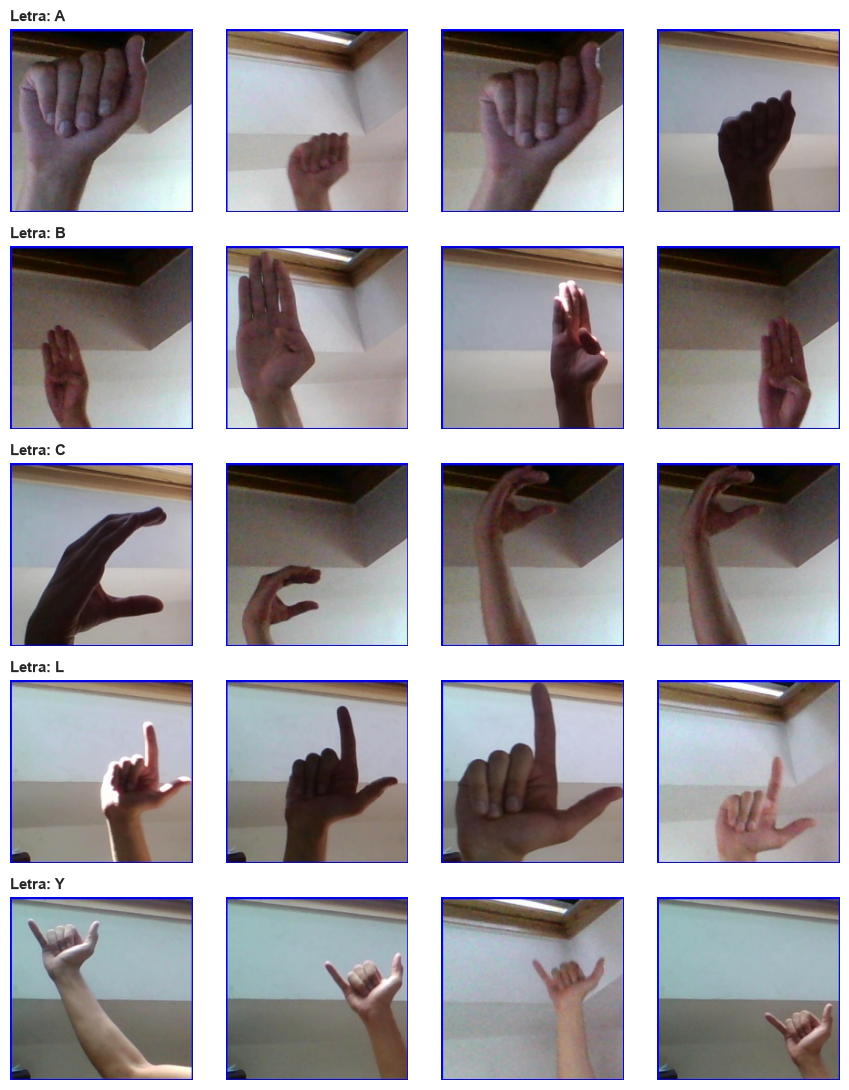

In [3]:
def show_letter_samples(letters, n_samples=4, seed=RANDOM_STATE):
    rng = random.Random(seed)
    fig, axes = plt.subplots(len(letters), n_samples, figsize=(n_samples * 2.2, len(letters) * 2.2))
    for i, letter in enumerate(letters):
        sample_paths = rng.sample(list(df[df.label == letter].filepath), n_samples)
        for j, p in enumerate(sample_paths):
            img = Image.open(p)
            ax = axes[i, j] if len(letters) > 1 else axes[j]
            ax.imshow(img)
            ax.axis("off")
            if j == 0:
                ax.set_ylabel(letter, fontsize=12)
        axes[i, 0].set_title(f"Letra: {letter}", loc="left", fontsize=11, fontweight="bold")
    plt.tight_layout()
    plt.show()

# 5 letras + varias muestras cada una, para ver variabilidad intra-clase
show_letter_samples(["A", "B", "C", "L", "Y"], n_samples=4)


**Hallazgo esperado:** dentro de una misma letra, las fotos varían en ángulo de la mano,
iluminación, tono de piel de quien hace la seña y fondo — pero la forma de la mano (la seña en sí)
se mantiene consistente. Esto es justo lo que necesitamos que el modelo aprenda a ignorar (fondo,
iluminación) para quedarse solo con la forma de la mano.

## Ejercicio 2 — Análisis exploratorio (EDA)

### 2.1 Resolución y formato de las imágenes

In [10]:
sample_paths = df.sample(300, random_state=RANDOM_STATE).filepath
sizes, modes, formats = [], [], []
for p in sample_paths:
    with Image.open(p) as img:
        sizes.append(img.size)
        modes.append(img.mode)
        formats.append(img.format)

print("Tamaños únicos encontrados:", set(sizes))
print("Modos de color únicos:", set(modes))
print("Formatos únicos:", set(formats))

Tamaños únicos encontrados: {(200, 200)}
Modos de color únicos: {'RGB'}
Formatos únicos: {'JPEG'}


**Hallazgo esperado:** el dataset documenta imágenes de 200x200 a color (RGB, .jpg) — esto
debería confirmarse con la celda de arriba. Si todas las imágenes salen con el mismo tamaño y modo,
no hace falta un paso de "limpieza" de formatos raros, solo resize/normalización.

#### balanceado?

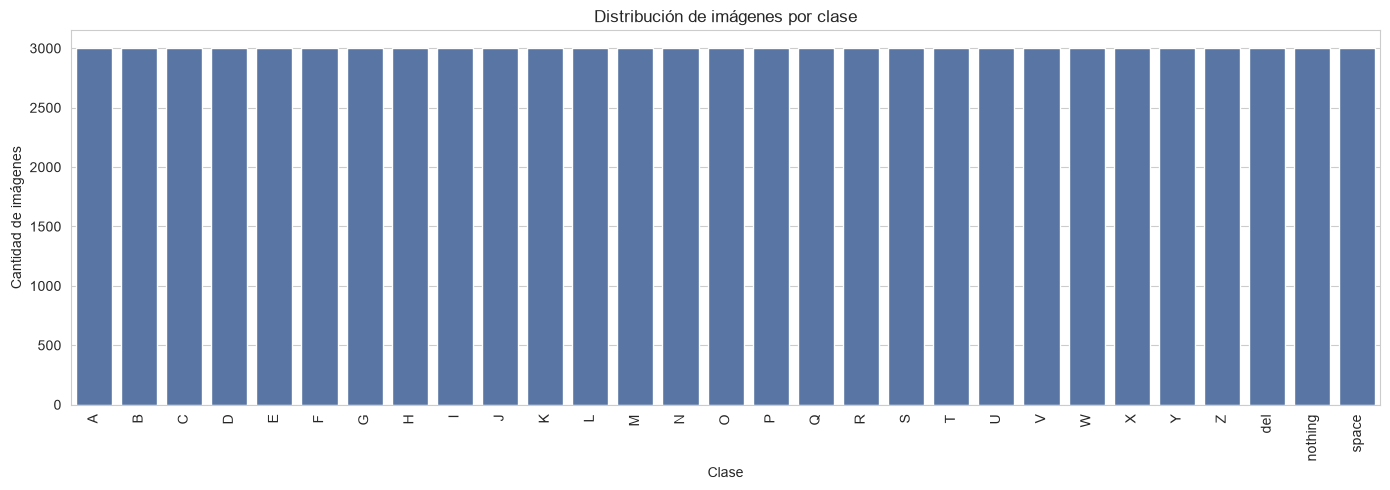

count      29.0
mean     3000.0
std         0.0
min      3000.0
25%      3000.0
50%      3000.0
75%      3000.0
max      3000.0
Name: count, dtype: float64

¿Balanceado? Sí


In [11]:
class_counts = df.label.value_counts().sort_index()

plt.figure(figsize=(14, 5))
sns.barplot(x=class_counts.index, y=class_counts.values, color="#4C72B0")
plt.xticks(rotation=90)
plt.ylabel("Cantidad de imágenes")
plt.xlabel("Clase")
plt.title("Distribución de imágenes por clase")
plt.tight_layout()
plt.show()

print(class_counts.describe())
print("\n¿Balanceado?", "Sí" if class_counts.std() / class_counts.mean() < 0.05 else "Revisar - puede haber desbalance")

**Hallazgo esperado:** el dataset ASL Alphabet de Kaggle trae ~3,000 imágenes por clase
(29 clases × 3,000 ≈ 87,000), por lo que suele salir bastante balanceado. Documenta aquí el
resultado real que te dio la celda — si alguna clase (por ejemplo NOTHING o SPACE) tiene menos
o más imágenes que las letras, coméntalo.

### 2.3 Letras visualmente similares (posible confusión del modelo)

Basado en la forma de la seña en ASL, hay grupos de letras que comparten una configuración de
mano muy parecida y solo se diferencian por detalles finos (posición del pulgar, orientación de
la palma, ligero movimiento en el caso de J/Z):

| Grupo | Por qué se confunden |
|---|---|
| **M, N, S** | Las tres son puños con el pulgar escondido bajo distintos dedos — la diferencia es de milímetros. |
| **U, V, R** | Dedos índice y medio extendidos, cambia solo si están juntos, separados o cruzados. |
| **K, V, P** | Configuración de dedos en V muy similar, cambia la orientación de la mano/muñeca. |
| **G, H** | Ambas usan índice (y medio en H) extendidos de lado, apuntando horizontal. |
| **A, T, S** | Puños cerrados con el pulgar en distinta posición. |

Vamos a graficar una muestra de cada grupo lado a lado para confirmar visualmente qué tan
parecidas se ven en la práctica (no solo en la teoría del alfabeto).

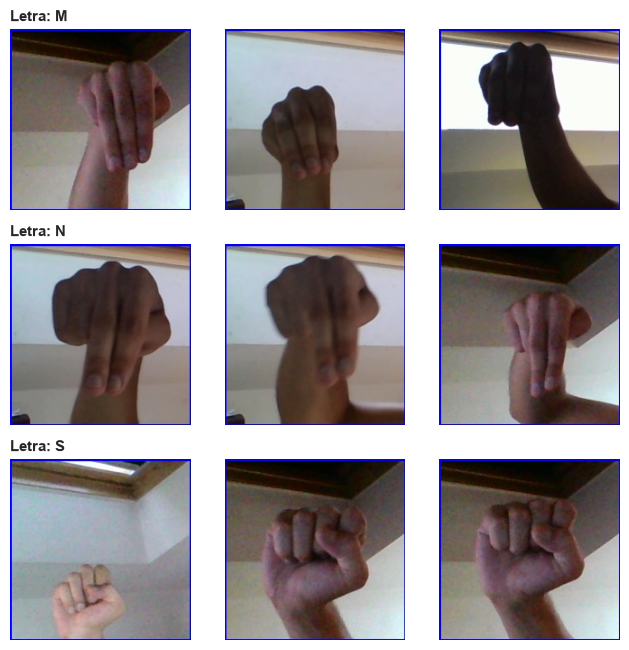

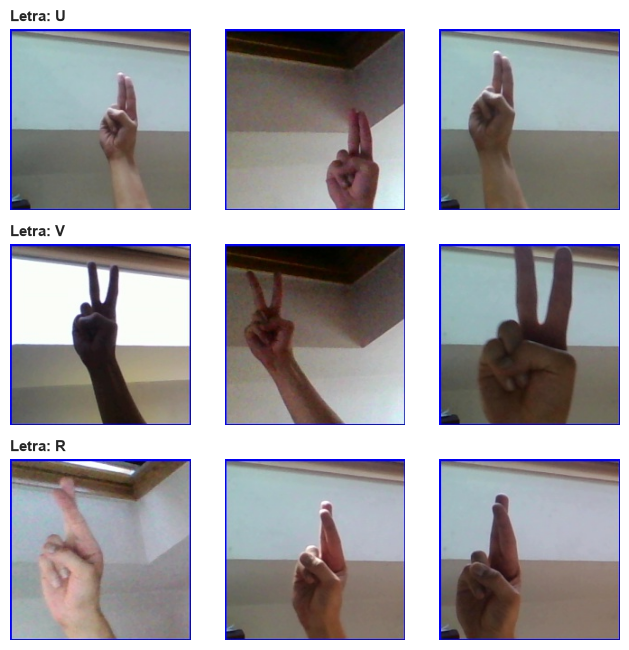

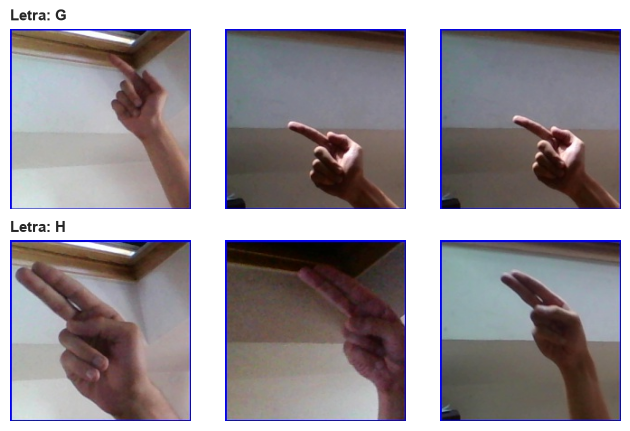

In [12]:
confusable_groups = [["M", "N", "S"], ["U", "V", "R"], ["G", "H"]]

for group in confusable_groups:
    show_letter_samples(group, n_samples=3)


### 2.4 Definición de conjuntos de entrenamiento / validación / prueba

El set de test oficial de Kaggle solo trae 1 imagen por clase (a propósito, según el enunciado),
así que no sirve para evaluar de verdad. Construimos nuestro propio split **estratificado** por
clase a partir de `asl_alphabet_train/`, para que las proporciones de cada letra se mantengan
iguales en los 3 conjuntos:

- **70% train** — para entrenar los modelos
- **15% validation** — para tunear hiperparámetros y comparar modelos
- **15% test** — solo se usa una vez, al final, para reportar el desempeño real

In [13]:
train_df, temp_df = train_test_split(
    df, test_size=0.30, stratify=df.label, random_state=RANDOM_STATE
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df.label, random_state=RANDOM_STATE
)

print(f"Train: {len(train_df):,} ({len(train_df)/len(df):.1%})")
print(f"Val:   {len(val_df):,} ({len(val_df)/len(df):.1%})")
print(f"Test:  {len(test_df):,} ({len(test_df)/len(df):.1%})")

# Verificación rápida de que el split sigue balanceado por clase
print("\nProporción de cada clase en train (debería ser pareja):")
print((train_df.label.value_counts(normalize=True) * 100).round(2).head())

Train: 60,900 (70.0%)
Val:   13,050 (15.0%)
Test:  13,050 (15.0%)

Proporción de cada clase en train (debería ser pareja):
label
V    3.45
S    3.45
O    3.45
R    3.45
N    3.45
Name: proportion, dtype: float64


## Ejercicio 3 — Preprocesamiento de las imágenes
87,000 imágenes a color de 200x200 son ~250 MB solo en píxeles crudos por batch, y entrenar
varios modelos (2 CNNs + NN simple + otro algoritmo, cada uno con distintas configuraciones)
sobre el dataset completo no es viable en el tiempo del laboratorio.

**Decisión:** tomamos una submuestra de **600 imágenes por clase** (≈17,400 imágenes en total),
manteniendo el split estratificado 70/15/15 ya definido. 600 imágenes por clase sigue siendo
suficiente para que una CNN pequeña generalice razonablemente, y reduce el volumen de datos
en aproximadamente 5x frente al dataset completo.

In [14]:
N_PER_CLASS = 600

def stratified_subsample(data, n_per_class, seed=RANDOM_STATE):
    return (
        data.groupby("label", group_keys=False)
        .apply(lambda x: x.sample(min(n_per_class, len(x)), random_state=seed))
        .reset_index(drop=True)
    )

train_sub = stratified_subsample(train_df, int(N_PER_CLASS * 0.70))
val_sub = stratified_subsample(val_df, int(N_PER_CLASS * 0.15))
test_sub = stratified_subsample(test_df, int(N_PER_CLASS * 0.15))

print(f"Train (submuestra): {len(train_sub):,}")
print(f"Val (submuestra):   {len(val_sub):,}")
print(f"Test (submuestra):  {len(test_sub):,}")

Train (submuestra): 12,180
Val (submuestra):   2,610
Test (submuestra):  2,610


### 3.2 Resize y normalización

Reducimos la resolución de 200x200 a **64x64**. Para un problema de forma de mano
(no de detalle fino tipo texto), 64x64 conserva suficiente información de la silueta de los dedos
y reduce el tamaño de cada imagen ~10x (200x200x3 = 120,000 valores vs 64x64x3 = 12,288),
lo que acelera bastante el entrenamiento de las CNNs.

Normalizamos los valores de píxel dividiendo entre 255 para que queden en el rango [0, 1],
que es lo que esperan la mayoría de arquitecturas de redes neuronales.

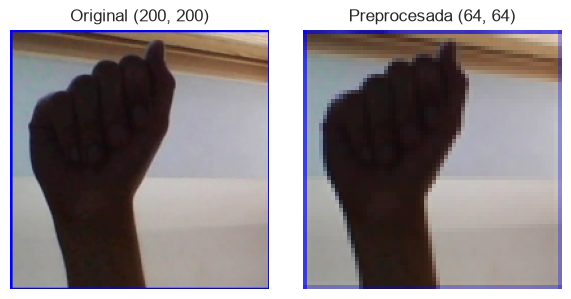

In [15]:
IMG_SIZE = 64

def load_and_preprocess(filepath, size=IMG_SIZE):
    img = Image.open(filepath).convert("RGB").resize((size, size))
    arr = np.asarray(img, dtype=np.float32) / 255.0
    return arr

# Ejemplo: antes / después de preprocesar
example_path = train_sub.filepath.iloc[0]
original = Image.open(example_path)
processed = load_and_preprocess(example_path)

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(original)
axes[0].set_title(f"Original {original.size}")
axes[0].axis("off")
axes[1].imshow(processed)
axes[1].set_title(f"Preprocesada {processed.shape[:2]}")
axes[1].axis("off")
plt.tight_layout()
plt.show()
